# XGBoost Model v3
### Key changes vs previous version:
- **Leakage fix** — item-level stats (avg rating, popularity) frozen from training users only, then applied to test
- **XGBoost only** — cleaner, easier to tune; ensemble added marginal value at cost of instability
- **Optuna hyperparameter search** (60 trials, 3-fold inner CV)

### Changes since v2
- Adjust optuma hyper param tuner from 2.0 to 4.0 (increase penalty for missed positives) hopefully this will improve recall
- Use auc instead of AUC to use recall and precision as a measure of performance 

In [1]:
!pip install scikit-learn
import pandas as pd
import numpy as np
import zipfile, warnings
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
from scipy.stats import entropy
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\65837\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
C:\Users\65837\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## Feature Engineering (leakage-safe)

In [2]:
TOTAL_ITEMS = 1000

def compute_item_stats(XX_train):
    """Call ONCE on training interactions only. Returns frozen item-level stats."""
    item_avg = XX_train.groupby('item')['rating'].mean().rename('item_avg_rating')
    item_pop = XX_train.groupby('item')['user'].count().rename('item_popularity')
    return item_avg, item_pop


def build_features(XX_input, item_avg=None, item_pop=None):
    """
    Build user-level features.
    Always pass item_avg + item_pop from training when processing test data.
    """
    if item_avg is None:
        item_avg = XX_input.groupby('item')['rating'].mean().rename('item_avg_rating')
    if item_pop is None:
        item_pop = XX_input.groupby('item')['user'].count().rename('item_popularity')

    # Basic rating stats
    stats = XX_input.groupby('user')['rating'].agg(
        rating_mean='mean', rating_std='std', rating_median='median',
        rating_min='min',   rating_max='max', rating_count='count'
    )
    stats['rating_std']   = stats['rating_std'].fillna(0)
    stats['rating_range'] = stats['rating_max'] - stats['rating_min']

    # Rating proportions + entropy
    rdist  = XX_input.groupby(['user', 'rating']).size().unstack(fill_value=0)
    rdist  = rdist.reindex(columns=range(6), fill_value=0)
    rprops = rdist.div(rdist.sum(axis=1), axis=0)
    rprops.columns = [f'prop_rating_{i}' for i in range(6)]
    stats['rating_entropy'] = rprops.apply(lambda r: entropy(r[r > 0]), axis=1)
    stats = stats.join(rprops)

    # Extreme rating proportions (new v2)
    stats['prop_extreme'] = rprops['prop_rating_0'] + rprops['prop_rating_5']
    stats['prop_zero']    = rprops['prop_rating_0']
    stats['prop_five']    = rprops['prop_rating_5']

    # Item coverage (new v2)
    stats['unique_items_rated']  = XX_input.groupby('user')['item'].nunique()
    stats['item_coverage_ratio'] = stats['unique_items_rated'] / TOTAL_ITEMS

    # Item popularity (frozen)
    XX_pop = XX_input.merge(item_pop, left_on='item', right_index=True)
    pop_f  = XX_pop.groupby('user')['item_popularity'].agg(
        avg_item_popularity='mean', std_item_popularity='std'
    )
    pop_f['std_item_popularity'] = pop_f['std_item_popularity'].fillna(0)
    stats = stats.join(pop_f)

    # Deviation from item average (frozen)
    XX_dev = XX_input.merge(item_avg, left_on='item', right_index=True)
    XX_dev['deviation'] = XX_dev['rating'] - XX_dev['item_avg_rating']
    dev_f = XX_dev.groupby('user')['deviation'].agg(
        mean_deviation='mean', std_deviation='std',
        abs_mean_deviation=lambda x: np.mean(np.abs(x))
    )
    dev_f['std_deviation'] = dev_f['std_deviation'].fillna(0)
    stats = stats.join(dev_f)

    # Average quality of items targeted (new v2, frozen)
    iqf = XX_dev.groupby('user')['item_avg_rating'].agg(
        avg_item_avg_rating='mean', std_item_avg_rating='std'
    )
    iqf['std_item_avg_rating'] = iqf['std_item_avg_rating'].fillna(0)
    stats = stats.join(iqf)

    return stats.reset_index()

print('Feature builder defined.')

Feature builder defined.


## Load Data + Build Features

In [3]:
data   = np.load('first_batch.npz')
print(data.files)
data = np.load('first_batch.npz')
X = data['X']
print(X.shape)
print(X[:5])
XX_all = pd.DataFrame(data['X'], columns=['user', 'item', 'rating'])
yy_all = pd.DataFrame(data['y'], columns=['user', 'label'])

# Use ALL data — no train/test split
item_avg, item_pop = compute_item_stats(XX_all)

all_feats = build_features(XX_all, item_avg=item_avg, item_pop=item_pop).merge(yy_all, on='user')

feature_cols = [c for c in all_feats.columns if c not in ['user', 'label']]

X_trainval   = all_feats[feature_cols].values
y_trainval   = all_feats['label'].values

scaler       = RobustScaler()
X_trainval_s = scaler.fit_transform(X_trainval)

# Save for compatibility
all_feats.to_csv('training_features_with_labels.csv', index=False)

all_users = yy_all['user'].nunique()
print(f'Total users:  {all_users}')
print(f'Total samples:{len(y_trainval)}')
print(f'Features:     {len(feature_cols)}')
print('Saved: training_features_with_labels.csv')

['X']
(167493, 3)
[[2974    5    2]
 [2974   11    3]
 [2974   14    3]
 [2974   17    3]
 [2974   19    4]]


KeyError: 'y is not a file in the archive'

## Optuna Hyperparameter Search (60 trials)

In [ ]:
!pip install scikit-learn

spw_global = np.sum(y_trainval == 0) / np.sum(y_trainval == 1)

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1200),
        max_depth         = trial.suggest_int('max_depth', 3, 8),
        learning_rate     = trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.4, 1.0),
        colsample_bylevel = trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        gamma             = trial.suggest_float('gamma', 0.0, 1.0),
        reg_alpha         = trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        scale_pos_weight  = trial.suggest_float('scale_pos_weight',
                                                 spw_global * 0.5, spw_global * 3.0),
    )
    cv   = StratifiedKFold(n_splits=3, shuffle=True, random_state=trial.number)
    aucs = []
    for tr_i, val_i in cv.split(X_trainval_s, y_trainval):
        m = xgb.XGBClassifier(
            **params, eval_metric='auc', early_stopping_rounds=40,
            random_state=42, n_jobs=-1, tree_method='hist'
        )
        m.fit(X_trainval_s[tr_i], y_trainval[tr_i],
              eval_set=[(X_trainval_s[val_i], y_trainval[val_i])], verbose=False)
        aucs.append(roc_auc_score(y_trainval[val_i],
                                   m.predict_proba(X_trainval_s[val_i])[:, 1]))
    return np.mean(aucs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=60, show_progress_bar=True)

best_params = study.best_params
print(f'Best CV AUC: {study.best_value:.4f}')
print('Best params:', best_params)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\65837\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


Best trial: 11. Best value: 0.918477: 100%|██████████| 60/60 [00:32<00:00,  1.87it/s]

Best CV AUC: 0.9185
Best params: {'n_estimators': 727, 'max_depth': 4, 'learning_rate': 0.028739145495751402, 'subsample': 0.99925712240377, 'colsample_bytree': 0.6037098837802092, 'colsample_bylevel': 0.6060004330897604, 'min_child_weight': 4, 'gamma': 0.12190333274822399, 'reg_alpha': 0.024592200101839375, 'reg_lambda': 0.04298448767948916, 'scale_pos_weight': 6.733485117069881}


## 5-Fold CV with Best Params

In [ ]:
skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs_cv    = []
oof_scores = np.zeros(len(X_trainval_s))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_trainval_s, y_trainval)):
    X_tr, X_val = X_trainval_s[tr_idx], X_trainval_s[val_idx]
    y_tr, y_val = y_trainval[tr_idx], y_trainval[val_idx]

    m = xgb.XGBClassifier(
        **best_params, eval_metric='auc', early_stopping_rounds=100,
        random_state=42, n_jobs=-1, tree_method='hist'
    )
    m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    p_val = m.predict_proba(X_val)[:, 1]
    oof_scores[val_idx] = p_val
    auc = roc_auc_score(y_val, p_val)
    aucs_cv.append(auc)
    print(f'Fold {fold+1}:  XGB={auc:.4f}')

oof_auc = roc_auc_score(y_trainval, oof_scores)
print(f'\n=== CV Results ===')
print(f'XGBoost  AUC: {np.mean(aucs_cv):.4f} ± {np.std(aucs_cv):.4f}')
print(f'OOF AUC:      {oof_auc:.4f}')

Fold 1:  XGB=0.9324
Fold 2:  XGB=0.7447
Fold 3:  XGB=0.9418
Fold 4:  XGB=0.9164
Fold 5:  XGB=0.9715

=== CV Results ===
XGBoost  AUC: 0.9014 ± 0.0803
OOF AUC:      0.9046


## Final Model + Evaluation

In [ ]:
X_ft, X_es, y_ft, y_es = train_test_split(
    X_trainval_s, y_trainval, test_size=0.1, stratify=y_trainval, random_state=42
)
final_model = xgb.XGBClassifier(
    **best_params, eval_metric='auc', early_stopping_rounds=50,
    random_state=42, n_jobs=-1, tree_method='hist'
)
final_model.fit(X_ft, y_ft, eval_set=[(X_es, y_es)], verbose=False)

# Threshold search on OOF
oof_norm   = (oof_scores - oof_scores.min()) / (oof_scores.max() - oof_scores.min() + 1e-9)
thresholds = np.linspace(0.01, 0.99, 500)
j_scores, f1_scores_t, prec_list, rec_list = [], [], [], []

for t in thresholds:
    preds_t = (oof_norm >= t).astype(int)
    tp = np.sum((preds_t == 1) & (y_trainval == 1))
    tn = np.sum((preds_t == 0) & (y_trainval == 0))
    fp = np.sum((preds_t == 1) & (y_trainval == 0))
    fn = np.sum((preds_t == 0) & (y_trainval == 1))
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1_t = 2 * prec * sens / (prec + sens + 1e-9)
    j_scores.append(sens + spec - 1)
    f1_scores_t.append(f1_t)
    prec_list.append(prec)
    rec_list.append(sens)

best_j_idx  = np.argmax(j_scores)
best_f1_idx = np.argmax(f1_scores_t)
print(f"Optimal threshold — Youden's J : {thresholds[best_j_idx]:.3f}  "
      f"(prec={prec_list[best_j_idx]:.3f}, rec={rec_list[best_j_idx]:.3f})")
print(f"Optimal threshold — Best F1   : {thresholds[best_f1_idx]:.3f}  "
      f"(prec={prec_list[best_f1_idx]:.3f}, rec={rec_list[best_f1_idx]:.3f})")

best_threshold = thresholds[best_f1_idx]

y_score_test = final_model.predict_proba(X_test_s)[:, 1]
y_score_norm = (y_score_test - y_score_test.min()) / (y_score_test.max() - y_score_test.min() + 1e-9)
y_pred       = (y_score_norm >= best_threshold).astype(int)

auc       = roc_auc_score(y_test, y_score_test)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)

print('\n# XGBoost (held-out test set):')
print(f'# AUC:       {auc:.4f}')
print(f'# Precision: {precision:.4f}')
print(f'# Recall:    {recall:.4f}')
print(f'# F1 Score:  {f1:.4f}')

Optimal threshold — Youden's J : 0.365  (prec=0.435, rec=0.750)
Optimal threshold — Best F1   : 0.556  (prec=0.754, rec=0.575)

# XGBoost (held-out test set):
# AUC:       0.9233
# Precision: 0.8000
# Recall:    0.6000
# F1 Score:  0.6857


## Feature Importance

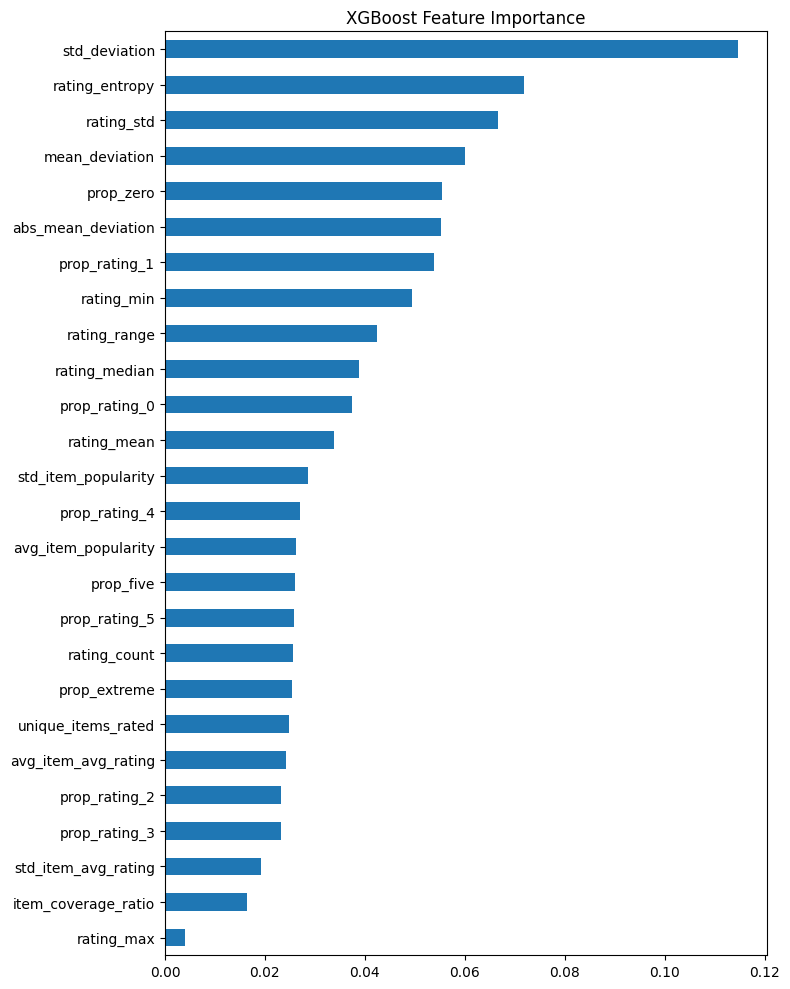

Top 10 features:
std_deviation         0.114661
rating_entropy        0.071836
rating_std            0.066575
mean_deviation        0.060013
prop_zero             0.055417
abs_mean_deviation    0.055322
prop_rating_1         0.053782
rating_min            0.049433
rating_range          0.042500
rating_median         0.038803
dtype: float32


In [ ]:
feat_imp = pd.Series(final_model.feature_importances_,
                     index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 10))
feat_imp.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()
print('Top 10 features:')
print(feat_imp.head(10))

## Build Test Features + Submit

In [ ]:
test_data   = np.load('subset_training_batch.npz')
XX_test_raw = pd.DataFrame(test_data['X'], columns=['user', 'item', 'rating'])

# Use FROZEN item stats — this is the leakage fix applied to Codabench submissions
test_feats = build_features(XX_test_raw, item_avg=item_avg, item_pop=item_pop)
test_feats.to_csv('test_features.csv', index=False)
print('Saved: test_features.csv')

X_unseen   = scaler.transform(test_feats[feature_cols].values)
y_unseen_s = final_model.predict_proba(X_unseen)[:, 1]

# Local AUC check
try:
    all_labels_df = pd.DataFrame(data['y'], columns=['user', 'label'])
    test_labels   = test_feats[['user']].merge(all_labels_df, on='user')['label'].values
    print(f'\nLocal AUC (trial set): {roc_auc_score(test_labels, y_unseen_s):.4f}')
except Exception as e:
    print(f'Could not compute local AUC: {e}')

# Save submission
y_unseen_norm = (y_unseen_s - y_unseen_s.min()) / (y_unseen_s.max() - y_unseen_s.min())
np.savez('submission.npz', predictions=y_unseen_norm)
with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('submission.npz', arcname='submission.npz')
print('Saved submission.npz and zipped to submission.zip — upload submission.zip to Codabench')

Saved: test_features.csv

Local AUC (trial set): 0.9703
Saved submission.npz and zipped to submission.zip — upload submission.zip to Codabench
